In [24]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings
import duckdb
import dill

warnings.filterwarnings("ignore")

# Repo root must be on sys.path before importing src (cwd varies by notebook folder).
PROJECT_ROOT = next(
    p for p in (Path.cwd(), *Path.cwd().parents)
    if (p / "src" / "config.py").is_file()
)
sys.path.insert(0, str(PROJECT_ROOT))

from src.config import PROCESSED_DIR, RAW_DIR
from src.analysis.metrics import EVENT_COLS
from src.analysis.passing.passing import (
    PASS_ANALYSIS_COLS,
    first_pass_direction_table,
    pressure_escape_table,
)
from src.analysis.possession.possession import build_possession_summary
from src.analysis.possession.compare import (
    build_event_style_table,
    build_passing_style_table,
    build_possession_style_table,
    longest_possessions,
    regular_play_start_zones,
    top_turnover_types,
)
from src.analysis.possession.viz import (
    plot_entry_rates,
    plot_first_pass_direction,
    plot_pass_angle_rose,
    plot_pass_count_distribution,
    plot_pass_height_comparison,
    plot_pass_length_histograms,
    plot_pass_network_heatmap,
    plot_pass_vs_carry_progression,
    plot_possession_duration_by_team,
    plot_possession_progression_scatter,
    plot_possession_start_end_heatmaps,
    plot_pressure_directness_scatter,
    plot_pressure_progression_split,
    plot_team_metric_comparison,
)

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

MATCH_ID = 3749493
TEAMS = ["Arsenal", "Everton"]

# dill.load_session('../saves/notebook_env.db')

In [5]:
events_path = PROCESSED_DIR / "events_2004.parquet"
match_cols = sorted(set(EVENT_COLS + PASS_ANALYSIS_COLS))
match_df = pd.read_parquet(events_path, columns=match_cols)
match_df = match_df[match_df["match_id"] == MATCH_ID].copy()

match_info = (
    pd.read_csv(PROCESSED_DIR / "matches_2004.csv")
    .loc[lambda d: d["match_id"] == MATCH_ID]
    .iloc[0]
)
print(
    f"{match_info['match_home_team']} {match_info['match_score']} "
    f"{match_info['match_away_team']} — {match_info['match_kickoff']}"
)
print(f"Events: {len(match_df):,}")


Arsenal 2 - 1 Everton — 2003-08-16 13:00:00.000
Events: 3,057


## Possession analysis

We want to see whether the possession was structured vs. chaotic using metrics, such as `duration`, `event_count`, `pass_count`. This helps us understand:

1. How long can the team sustain control?
2. Are possession deliberate or rushed?
3. Does the team recycle possession or attack immediately?

This should provide insight to whether or not the early 2000s premier league fit the stereotype that it had shorter possession, fewer actions, more transitions and quicker vertical attacks. Some other questions to consider:

- How efficiently does the team move upfield?
- Is progression gradual or explosive?
- Does buildup happen through controlled advancement?
- Can the team maintain possession under pressure?
- How does pressure affect possession length?
- Does the team break pressure structurally?
- Which possessions create danger?
- Are dangerous possessions long or short?
- Does the team create chances through structure or transition?


In [6]:
possession_summary = build_possession_summary(match_df)
possession_summary.to_csv(PROCESSED_DIR / "possession_summary.csv", index=False)

duckdb.register("possession_summary", possession_summary)
print(f"Possession chains: {len(possession_summary):,}")

Possession chains: 201


## Variables

The progression metrics that I gathered, detailed in the columns are:

### Identity
- `match_id`: StatsBomb match id
- `period`: Match period: 1 first half, 2 second half, etc.
- `possession_id`: StatsBomb possession chain id within the match
- `possession_team`: Team that controls the possession chain
- `play_pattern`: How the possession started, e.g. Regular Play, From Throw In, From Corner
- `opponent`: The opposing team in the match

### Time / Control
- `start_minute`: Minute of the first event in the possession
- `start_second`: Second of the first event in the possession
- `end_minute`: Minute of the final event in the possession
- `end_second`: Second of the final event in the possession
- `start_time`: Possession start time in seconds from period clock, calculated as minute * 60 + second
- `end_time`: Possession end time in seconds from period clock, calculated as minute * 60 + second
- `clock_duration`: Elapsed clock time of the possession in seconds
- `action_duration`: Sum of StatsBomb event duration values within the possession
- `avg_event_duration`: Average event duration within the possession
- `event_count`: Total number of events in the possession chain
- `pass_count`: Number of Pass events by the possession team
- `carry_count`: Number of Carry events by the possession team
- `touch_count`: pass_count + carry_count; rough proxy for controlled ball actions

### Tempo / Deliberateness
- `events_per_second`: Event density, calculated as event_count divided by clock_duration
- `passes_per_second`: Pass tempo, calculated as pass_count divided by clock_duration
- `directness_ratio`: Net x progression divided by total pass/carry distance. Near 1 means direct forward play, near 0 means recycling, and negative means backward movement

### Progression
- `start_x`: X coordinate of the possession team’s first on-ball location
- `start_y`: Y coordinate of the possession team’s first on-ball location
- `end_x`: X coordinate of the possession team’s final on-ball/end location
- `end_y`: Y coordinate of the possession team’s final on-ball/end location
- `net_x_progression`: end_x - start_x; how far upfield the possession ended relative to where it began
- `total_x_progression`: Sum of all positive x movement from possession-team passes and carries
- `progressive_distance`: Sum of large positive x movements, currently movements with x gain >= 10
- `max_x_reached`: Furthest x coordinate reached during the possession
- `final_third_entry`: True if the possession reached x >= 80
- `box_entry`: True if the possession reached the box area, defined as x >= 102 and 18 <= y <= 62

### Pressure
- `pressure_event_count`: Number of explicit opponent Pressure events during the possession
- `under_pressure_count`: Number of possession-team events marked under_pressure
- `pressure_rate`: under_pressure_count divided by possession-team event count
- `pressured_pass_count`: Number of possession-team passes made under pressure
- `pressured_pass_completion`: Completion rate of possession-team passes made under pressure
- `counterpress_faced`: Number of opponent events marked counterpress during the possession

### Outcome / Danger
- `shot_count`: Number of shots by the possession team in the possession
- `xg_created`: Sum of shot_statsbomb_xg from possession-team shots
- `key_pass_count`: Number of shot assists or goal assists in the possession
- `turnover_type`: Label inferred from the final possession-team event, e.g. Pass - Incomplete, Shot - Saved, Out
- `ends_with_shot`: True if the final possession-team event was a shot
- `ends_in_final_third`: True if the possession team’s final location was in the final third
- `ends_in_box`: True if the possession team’s final location was in the box


## Visuals

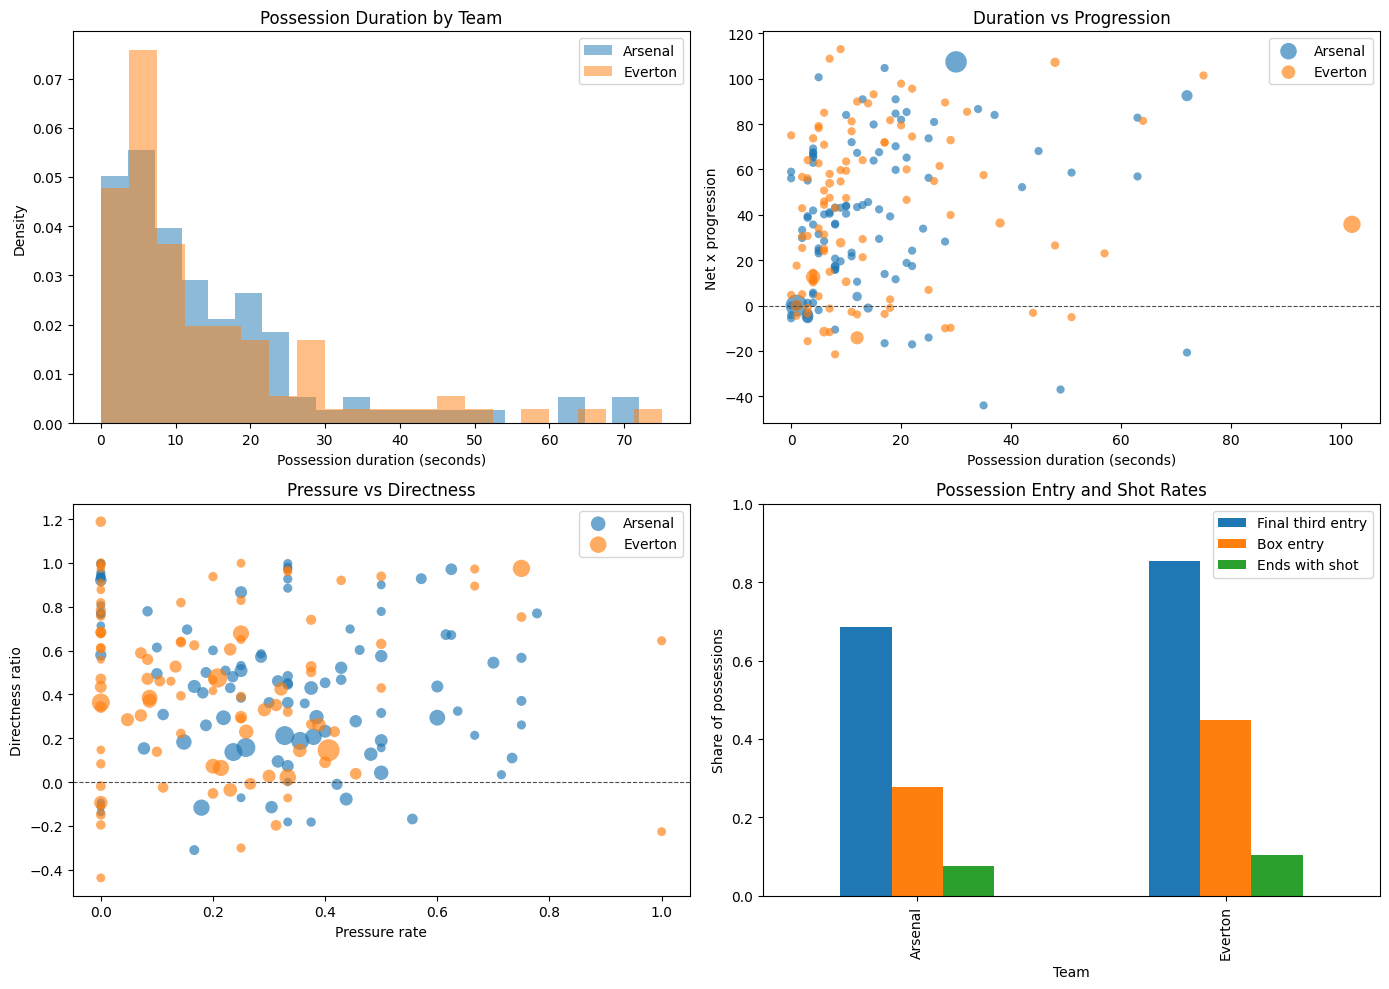

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_possession_duration_by_team(possession_summary, ax=axes[0, 0])
plot_possession_progression_scatter(possession_summary, ax=axes[0, 1])
plot_pressure_directness_scatter(possession_summary, ax=axes[1, 0])
plot_entry_rates(possession_summary, ax=axes[1, 1])

plt.tight_layout()
plt.show()

In [8]:
danger_cols = [
    "possession_team",
    "possession_id",
    "clock_duration",
    "pass_count",
    "net_x_progression",
    "directness_ratio",
    "pressure_rate",
    "xg_created",
    "box_entry",
    "turnover_type",
]

possession_summary.sort_values(
    ["xg_created", "box_entry", "net_x_progression"],
    ascending=[False, True, True],
)[danger_cols]

,possession_team,possession_id,clock_duration,pass_count,net_x_progression,directness_ratio,pressure_rate,xg_created,box_entry,turnover_type
73,Arsenal,74,1,0,0.0,NaN,0.000000,0.783500,True,Shot - Goal
131,Arsenal,131,30,6,107.4,0.428936,0.375000,0.747578,True,Shot - Goal
15,Everton,16,102,9,35.8,0.145135,0.406250,0.440552,True,Foul Won
158,Everton,158,4,1,12.6,-0.301131,0.250000,0.266854,True,Shot - Off T
181,Everton,181,12,6,-14.2,-0.197794,0.312500,0.200138,True,Shot - Goal
...,...,...,...,...,...,...,...,...,...,...
2,Arsenal,3,34,12,86.6,0.296346,0.384615,0.000000,True,Miscontrol
72,Arsenal,73,19,6,90.9,0.571011,0.285714,0.000000,True,Dribble - Incomplete
187,Everton,187,22,4,95.6,0.605244,0.230769,0.000000,True,Foul Committed
122,Everton,122,20,6,97.8,0.526779,0.133333,0.000000,True,Pass - Incomplete


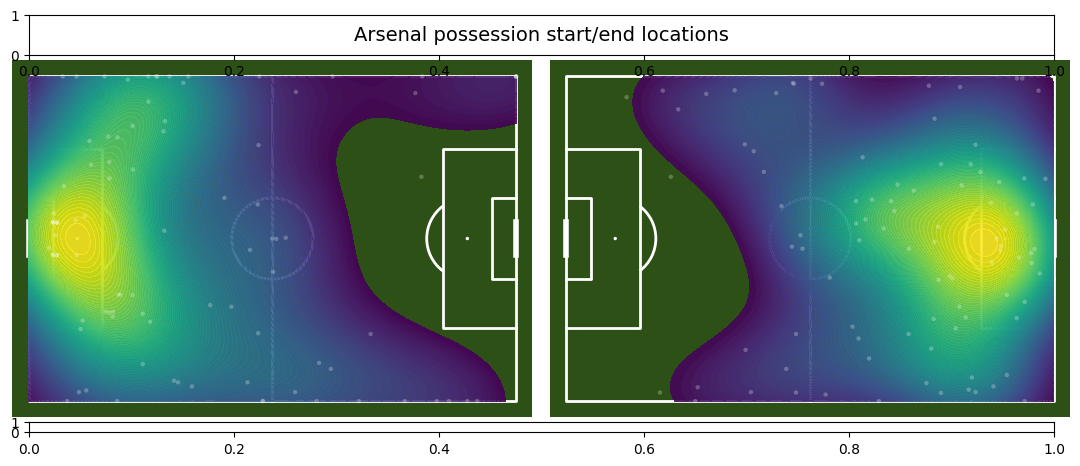

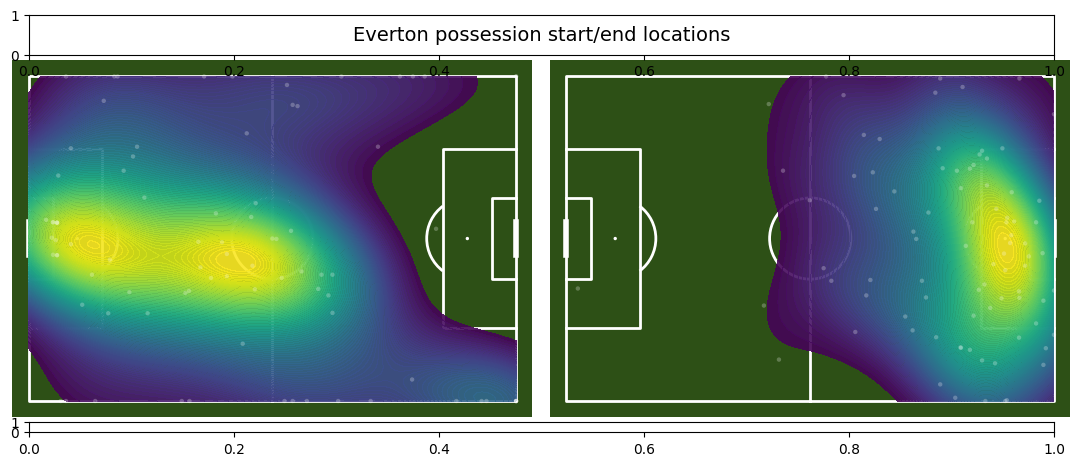

In [9]:
from IPython.display import display

for team in possession_summary["possession_team"].dropna().unique():

    fig = plot_possession_start_end_heatmaps(
        possession_summary,
        team=team,
        min_duration=3,
    )

    # display(fig)
    plt.show()

## Arsenal vs Everton — possession style (GW1, 2003/04)

Arsenal went unbeaten in 2003/04; this was their opening fixture (`match_id` 3749493). We compare possession-chain structure and event-level passing between the two sides.

**Pitch thirds** (StatsBomb x): defensive x < 40, midfield 40–80, attacking ≥ 80.


In [10]:
from IPython.display import display

TEAMS = ["Arsenal", "Everton"]

event_style = build_event_style_table(match_df, TEAMS)
possession_style = build_possession_style_table(possession_summary, TEAMS)
possession_style.to_csv(PROCESSED_DIR / "possession_style.csv", index=False)
event_style.to_csv(PROCESSED_DIR / "event_style.csv", index=False)

print("=== Event-level passing & physicality ===")
display(event_style.round(2))

=== Event-level passing & physicality ===


,team,events,passes,pass_completion_pct,avg_pass_length_m,long_pass_pct,crosses,through_balls,passes_into_final_third,pressure_on_pass_pct,...,high_pass_pct,carries,dribbles,dribbles_complete,counterpresses,duels,fouls_committed,shots,xg,goals
0,Arsenal,1584.0,422.0,77.01,23.57,24.41,7.0,0.0,127.0,28.44,...,22.27,342.0,29.0,13.0,37.0,28.0,11.0,14.0,2.12,2.0
1,Everton,1473.0,381.0,66.40,28.06,38.85,19.0,3.0,188.0,18.11,...,41.73,235.0,7.0,5.0,78.0,55.0,19.0,15.0,1.27,1.0


In this match in particular, we can see that Arsenal prefers short passess and building up possession, and progressing into the final third. Compared to Everton who prefers a more "long ball over the top" and leading to an attack that way. We can see this from `avg_pass_length_m`, with Arsenal's average pass length being 23.57m (24.41% of all their passes) while Everton's pass length was 28.06m (38.85%). Furthermore, the amount of `crosses`, `through_balls` and `passes_into_final_third`, supports this theory.

Using the number of `carries` and `dribbles`, we can see that Arsenal prefers holding onto the ball and building up the play. Although both teams had different playstyles, both teams lead to similar shots and `xg`, with Arsenal ultimately coming up on top winning 2-1.

In [11]:
print("=== Possession-chain style by scenario ===")
display(
    possession_style.round(2).pivot(
        index="scenario", columns="team", values="median_passes"
    )
)
display(possession_style.round(2))

=== Possession-chain style by scenario ===


team,Arsenal,Everton
scenario,,
All possessions,3.0,3.0
Regular Play,4.0,4.0
Regular Play (4+ passes),5.5,6.0
Regular Play (6+ passes),7.5,7.0


,scenario,team,possessions,median_events,median_passes,median_duration_sec,median_events_per_sec,median_directness,mean_directness,median_net_x,...,box_entry_pct,ends_final_third_pct,ends_box_pct,pressure_rate_pct,pressured_pass_completion_pct,ends_with_shot_pct,poss_with_shot_pct,total_xg,mean_start_x,mean_end_x
0,All possessions,Arsenal,105.0,12.0,3.0,10.0,1.25,0.45,0.44,39.0,...,27.62,57.14,22.86,30.09,73.43,7.62,10.48,2.12,43.92,81.23
1,All possessions,Everton,96.0,9.5,3.0,9.0,1.08,0.45,0.43,43.0,...,44.79,77.08,32.29,21.13,70.33,10.42,13.54,1.27,52.22,93.51
2,Regular Play,Arsenal,38.0,16.0,4.0,11.5,1.35,0.45,0.40,36.1,...,23.68,42.11,18.42,35.52,79.42,5.26,5.26,0.13,29.81,69.48
3,Regular Play,Everton,32.0,16.0,4.0,13.0,1.00,0.46,0.40,54.7,...,37.50,56.25,21.88,26.72,83.33,3.12,6.25,0.45,41.40,87.64
4,Regular Play (4+ passes),Arsenal,20.0,21.0,5.5,20.0,1.26,0.45,0.38,60.1,...,40.00,55.00,30.00,31.04,80.98,5.00,5.00,0.11,31.31,83.24
5,Regular Play (4+ passes),Everton,19.0,19.0,6.0,20.0,1.00,0.33,0.33,61.5,...,52.63,73.68,26.32,19.54,76.19,5.26,10.53,0.45,36.60,92.94
6,Regular Play (6+ passes),Arsenal,10.0,28.5,7.5,23.5,1.11,0.20,0.25,60.1,...,40.00,50.00,20.00,29.47,86.00,10.00,10.00,0.11,34.15,82.99
7,Regular Play (6+ passes),Everton,11.0,27.0,7.0,29.0,0.86,0.33,0.32,72.9,...,63.64,90.91,36.36,19.98,74.07,9.09,18.18,0.45,31.80,97.57


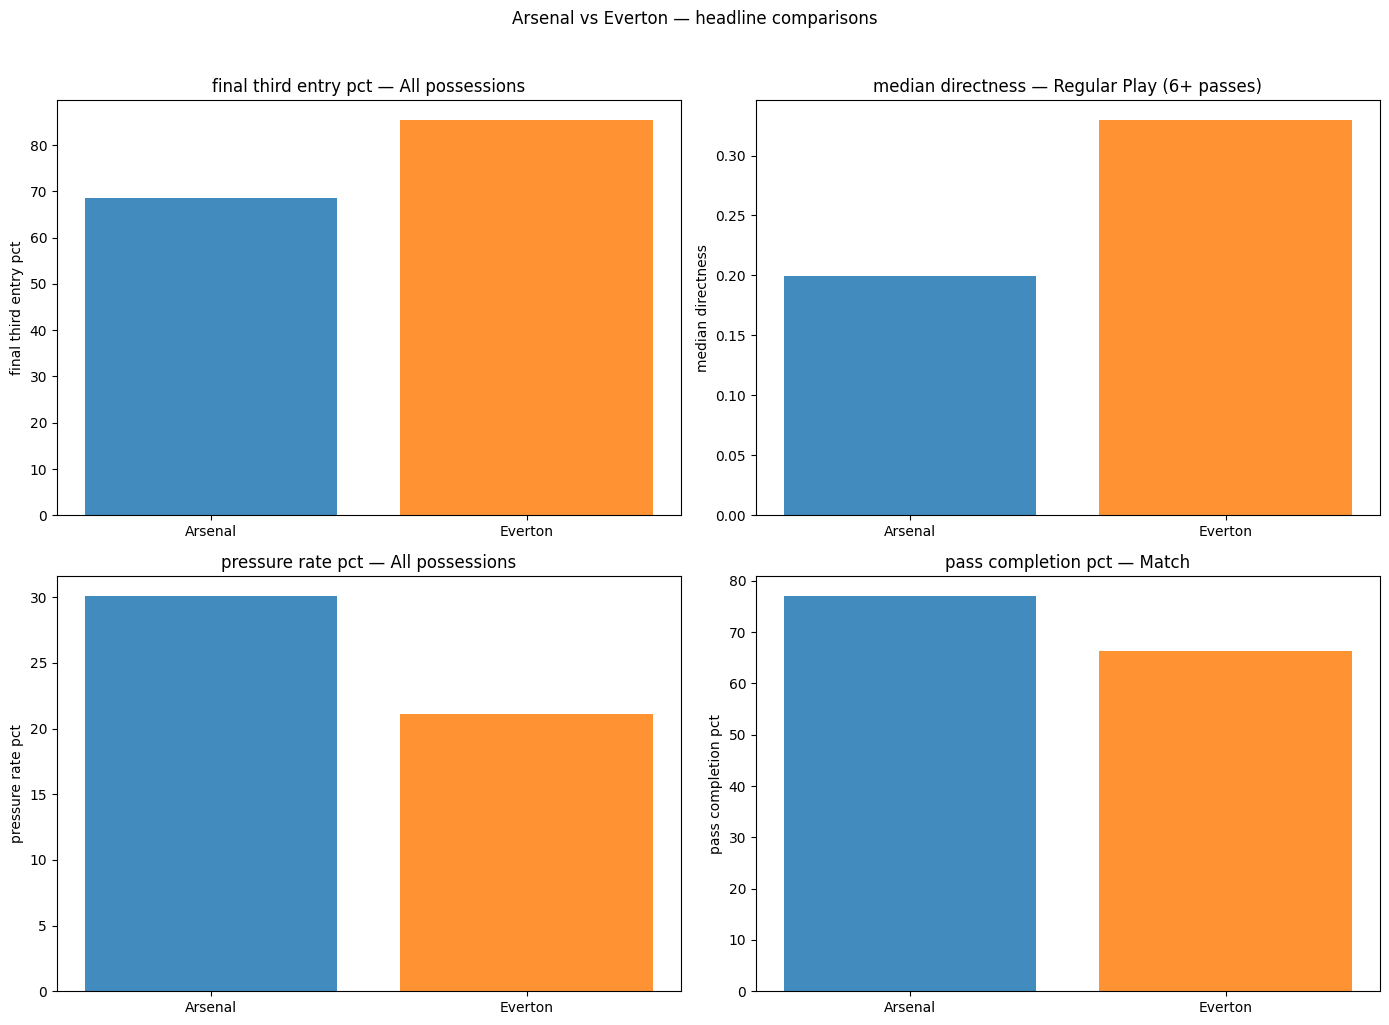

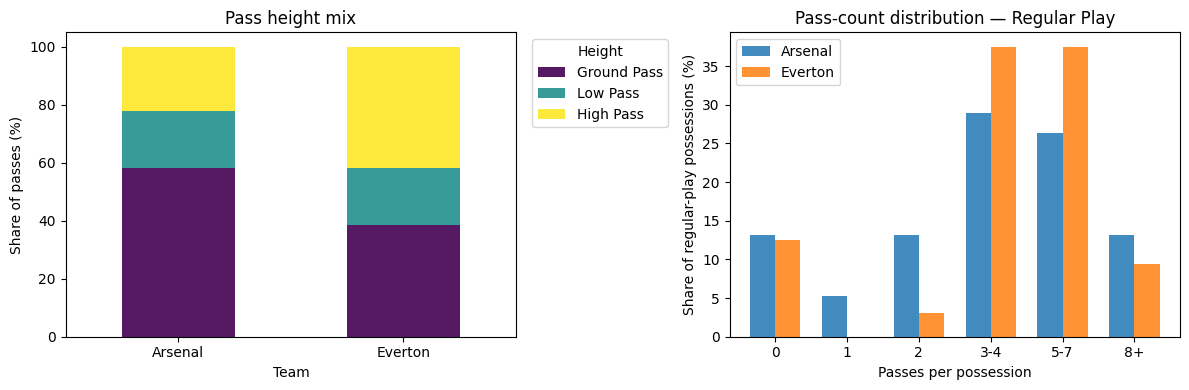

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

plot_team_metric_comparison(
    possession_style, "final_third_entry_pct",
    scenario="All possessions", ax=axes[0, 0],
)
plot_team_metric_comparison(
    possession_style, "median_directness",
    scenario="Regular Play (6+ passes)", ax=axes[0, 1],
)
plot_team_metric_comparison(
    possession_style, "pressure_rate_pct",
    scenario="All possessions", ax=axes[1, 0],
)
event_plot = event_style.copy()
event_plot["scenario"] = "Match"
plot_team_metric_comparison(
    event_plot, "pass_completion_pct",
    scenario="Match", ax=axes[1, 1],
)

fig.suptitle("Arsenal vs Everton — headline comparisons", y=1.02)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pass_height_comparison(match_df, TEAMS, ax=axes[0])
plot_pass_count_distribution(possession_summary, TEAMS, ax=axes[1])
plt.tight_layout()
plt.show()


In [13]:
print("=== Regular Play — where possessions start ===")
for team in TEAMS:
    zones = regular_play_start_zones(possession_summary, team)
    total = zones["count"].sum()
    print(f"\n{team} ({total} chains):")
    for _, row in zones.iterrows():
        pct = row["count"] / total * 100
        print(f"  {row['start_zone']:10s}: {row['count']:3d} ({pct:.0f}%)")

print("\n=== How possessions end (top turnover types) ===")
for team in TEAMS:
    print(f"\n{team}:")
    print(top_turnover_types(possession_summary, team).to_string())


=== Regular Play — where possessions start ===

Arsenal (37 chains):
  defensive :  30 (81%)
  midfield  :   6 (16%)
  attacking :   1 (3%)

Everton (31 chains):
  midfield  :  18 (58%)
  defensive :  13 (42%)

=== How possessions end (top turnover types) ===

Arsenal:
turnover_type
Ball Receipt*           26
Foul Won                12
Pass - Incomplete       12
Miscontrol              10
Dribble - Incomplete    10
Dispossessed             8
Shot - Off T             6
Pressure                 6

Everton:
turnover_type
Ball Receipt*        29
Pass - Incomplete    17
Foul Won              8
Pass - Out            6
Dispossessed          5
Duel                  4
Pressure              4
Foul Committed        4


In [16]:
print("=== Longest possessions (by pass count) ===")
for team in TEAMS:
    print(f"\n{team}:")
    display(longest_possessions(possession_summary, team))


=== Longest possessions (by pass count) ===

Arsenal:


,possession_id,play_pattern,pass_count,event_count,clock_duration,directness_ratio,net_x_progression,final_third_entry,xg_created
78,79,Regular Play,21,78,72,0.211871,92.5,True,0.106324
46,47,Regular Play,20,82,72,0.157343,-20.7,True,0.000000
81,82,From Free Kick,17,68,63,0.136809,56.9,True,0.000000
1,2,From Kick Off,15,51,49,-0.117140,-37.0,True,0.000000
138,138,Regular Play,15,62,63,0.187699,82.8,True,0.000000



Everton:


,possession_id,play_pattern,pass_count,event_count,clock_duration,directness_ratio,net_x_progression,final_third_entry,xg_created
143,143,From Throw In,16,53,48,0.064286,26.5,True,0.000000
114,114,From Goal Kick,11,34,44,0.385506,-3.2,True,0.000000
71,72,Regular Play,10,29,22,0.303621,74.5,True,0.000000
137,137,From Throw In,10,38,29,0.144186,39.9,True,0.000000
15,16,Regular Play,9,49,102,0.145135,35.8,True,0.440552


## Passing analysis — intention & structure (Regular Play)

Possession chains tell us how long Arsenal and Everton controlled the ball. This section looks at what their passes were trying to do inside **Regular Play**: where passes pointed, how connected the passing network was, how each team began possessions, how they passed under pressure, and whether progression came mainly through passes or carries.

In [17]:
passing_style = build_passing_style_table(match_df, TEAMS)
passing_style.to_csv(PROCESSED_DIR / "passing_style.csv", index=False)
duckdb.register("passing_style", passing_style)

passing_overview_cols = [
    "team",
    "passes",
    "verticality",
    "forward_pass_pct",
    "lateral_circulation_pct",
    "angle_entropy",
    "centralization",
    "connectivity",
    "clustering",
    "pressured_completion_pct",
    "pass_progression_share_pct",
    "carry_progression_share_pct",
]

display(passing_style[passing_overview_cols].round(2))

,team,passes,verticality,forward_pass_pct,lateral_circulation_pct,angle_entropy,centralization,connectivity,clustering,pressured_completion_pct,pass_progression_share_pct,carry_progression_share_pct
0,Arsenal,174.0,0.37,66.09,42.53,2.82,0.09,0.45,0.75,78.85,74.86,25.14
1,Everton,150.0,0.25,59.33,51.33,2.89,0.09,0.34,0.62,77.14,80.67,19.33


### 2.1 Geometry

Geometry focuses on pass intention at the event level. `verticality` measures how much passes point forward relative to their total distance. `lateral_circulation_pct` captures sideways circulation, and `angle_entropy` measures how varied the passing directions are.

,team,passes,verticality,forward_pass_pct,backward_pass_pct,lateral_pass_pct,lateral_circulation_pct,angle_entropy
0,Arsenal,174.0,0.37,66.09,21.84,12.07,42.53,2.82
1,Everton,150.0,0.25,59.33,29.33,11.33,51.33,2.89


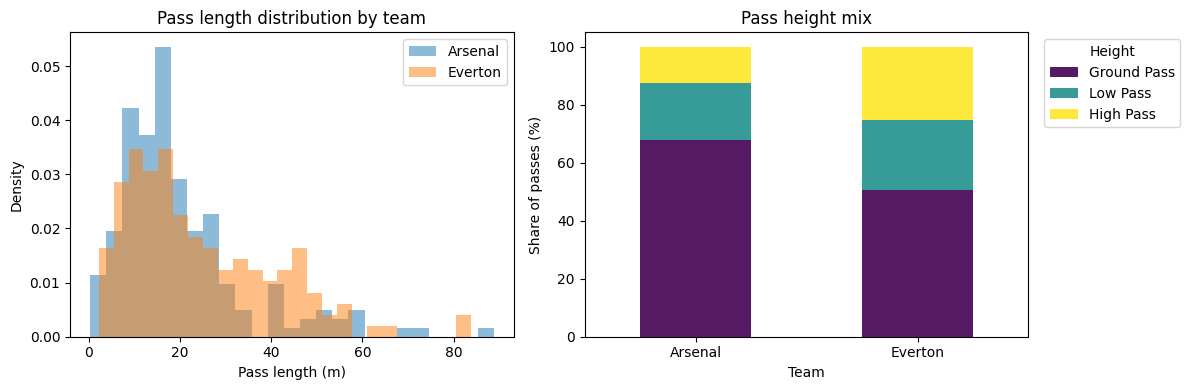

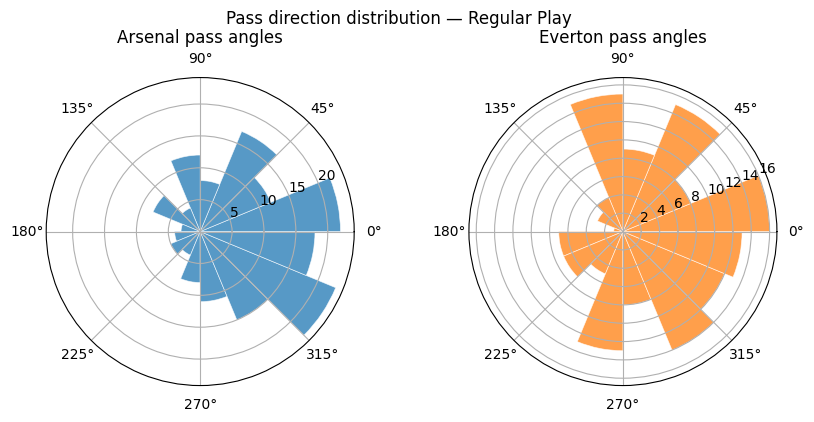

In [18]:
geometry_cols = [
    "team",
    "passes",
    "verticality",
    "forward_pass_pct",
    "backward_pass_pct",
    "lateral_pass_pct",
    "lateral_circulation_pct",
    "angle_entropy",
]

display(passing_style[geometry_cols].round(2))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pass_length_histograms(
    match_df,
    seasons=None,
    teams=TEAMS,
    play_pattern="Regular Play",
    bins=25,
    ax=axes[0],
)
plot_pass_height_comparison(
    match_df[match_df["play_pattern"] == "Regular Play"],
    TEAMS,
    ax=axes[1],
)
plt.tight_layout()
plt.show()

plot_pass_angle_rose(match_df, TEAMS, play_pattern="Regular Play")
plt.show()

### 2.2 Network structure

The pass network uses completed Regular Play passes and `pass_recipient`. `centralization` rises when a small number of players dominate involvement, `connectivity` measures how many possible player-to-player links were used, and `clustering` measures whether connected players formed local triangles.

,team,network_players,centralization,connectivity,clustering
0,Arsenal,13.0,0.088,0.449,0.747
1,Everton,14.0,0.089,0.341,0.625


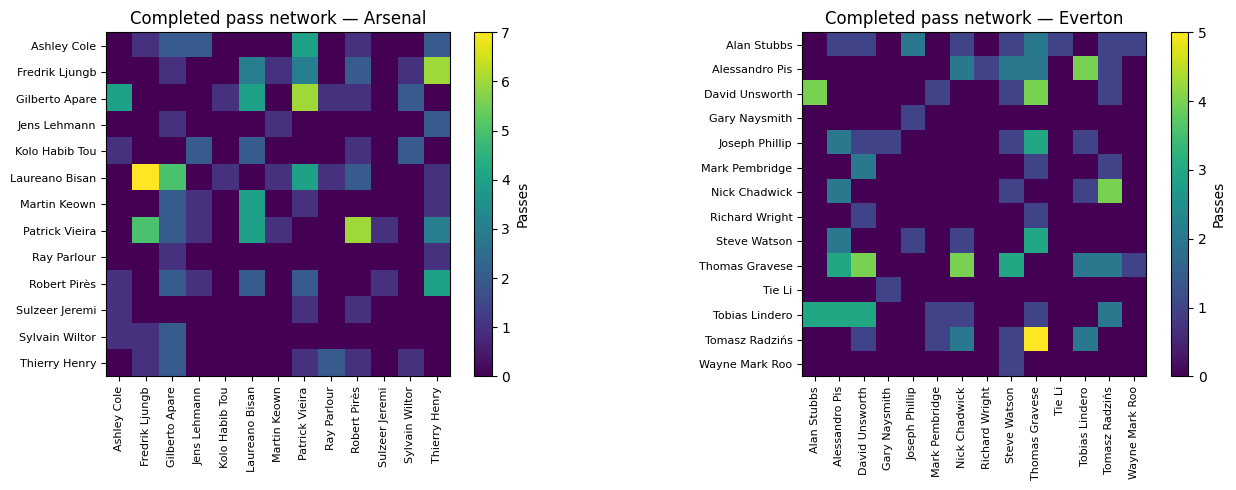

In [19]:
network_cols = ["team", "network_players", "centralization", "connectivity", "clustering"]
display(passing_style[network_cols].round(3))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, team in zip(axes, TEAMS):
    plot_pass_network_heatmap(match_df, team, ax=ax)
plt.tight_layout()
plt.show()

### 2.3 Build-up patterns

This section isolates the **first pass** of each Regular Play possession. It helps distinguish a team that uses the first pass to secure possession from a team that immediately pushes forward. Endpoint spread (`avg_endpoint_width_std` and `avg_endpoint_depth_std`) gives a simple proxy for whether longer possessions expand across width or depth.

,team,direction,count,pct
0,Arsenal,forward,28,73.68
1,Arsenal,lateral,3,7.89
2,Arsenal,backward,7,18.42
3,Everton,forward,23,65.71
4,Everton,lateral,2,5.71
5,Everton,backward,10,28.57


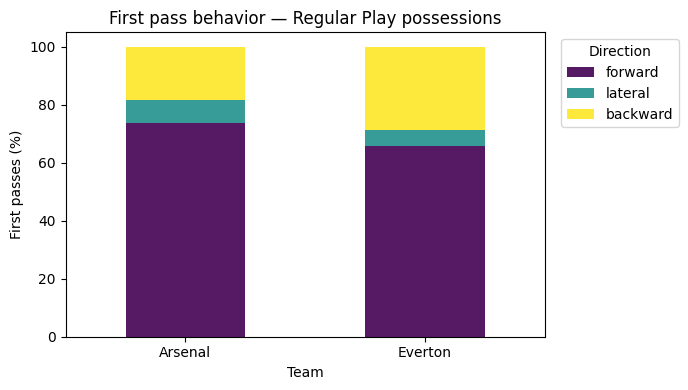

,team,first_forward_pct,first_backward_pct,first_lateral_pct,first_short_pct,first_long_pct,first_from_defensive_third_pct,first_into_midfield_or_better_pct,avg_endpoint_width_std,avg_endpoint_depth_std
0,Arsenal,73.68,18.42,7.89,36.84,63.16,73.68,57.89,15.68,18.37
1,Everton,65.71,28.57,5.71,42.86,57.14,40.00,74.29,17.20,21.20


In [20]:
first_pass = first_pass_direction_table(match_df, TEAMS)
display(first_pass.round(2))

fig, ax = plt.subplots(figsize=(7, 4))
plot_first_pass_direction(first_pass, ax=ax)
plt.tight_layout()
plt.show()

buildup_cols = [
    "team",
    "first_forward_pct",
    "first_backward_pct",
    "first_lateral_pct",
    "first_short_pct",
    "first_long_pct",
    "first_from_defensive_third_pct",
    "first_into_midfield_or_better_pct",
    "avg_endpoint_width_std",
    "avg_endpoint_depth_std",
]
display(passing_style[buildup_cols].round(2))

### 2.4 Pressure passing

Pressure passing separates stability from ambition. Completion under pressure shows ball security, while `pressured_mean_dx` shows whether pressured passes still moved forward. The escape structure classifies the next same-team action after a pressured pass.

,team,pressured_pass_pct,pressured_completion_pct,unpressured_completion_pct,pressured_mean_dx,unpressured_mean_dx,pressure_escape_forward_pass_pct,pressure_escape_positive_carry_pct,pressure_escape_turnover_pct
0,Arsenal,29.89,78.85,84.43,6.95,9.61,0.0,0.0,1.92
1,Everton,23.33,77.14,73.91,11.50,9.62,0.0,0.0,2.86


,team,escape_type,pct
0,Arsenal,retained_other,98.1
1,Arsenal,turnover,1.9
2,Everton,retained_other,97.1
3,Everton,turnover,2.9


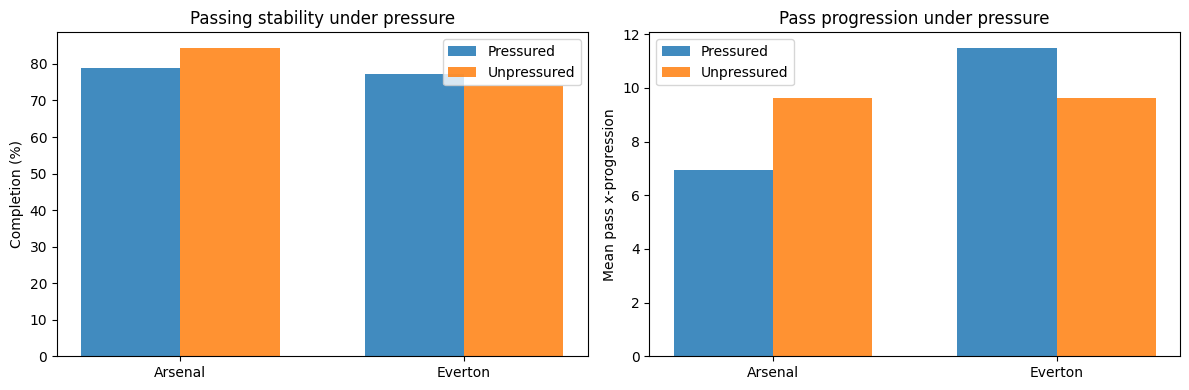

In [21]:
pressure_cols = [
    "team",
    "pressured_pass_pct",
    "pressured_completion_pct",
    "unpressured_completion_pct",
    "pressured_mean_dx",
    "unpressured_mean_dx",
    "pressure_escape_forward_pass_pct",
    "pressure_escape_positive_carry_pct",
    "pressure_escape_turnover_pct",
]
display(passing_style[pressure_cols].round(2))

escape_rows = []
for team in TEAMS:
    escapes = pressure_escape_table(match_df, team)
    if escapes.empty:
        continue
    rates = escapes["escape_type"].value_counts(normalize=True).mul(100).round(1)
    for escape_type, pct in rates.items():
        escape_rows.append({"team": team, "escape_type": escape_type, "pct": pct})
escape_summary = pd.DataFrame(escape_rows)
display(escape_summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_pressure_progression_split(passing_style, metric="completion", ax=axes[0])
plot_pressure_progression_split(passing_style, metric="dx", ax=axes[1])
plt.tight_layout()
plt.show()

### 2.5 Progression mechanism

This compares whether open-play progression came through passes or carries. `positive_pass_progression` and `positive_carry_progression` sum only forward x-gains, so the shares describe the mechanism used to advance the ball rather than total activity volume.

,team,positive_pass_progression,positive_carry_progression,pass_progression_share_pct,carry_progression_share_pct,progression_per_pass,progression_per_carry,progressive_pass_pct,progressive_carry_pct
0,Arsenal,1968.1,661.0,74.86,25.14,8.82,3.19,41.38,15.24
1,Everton,1865.5,447.0,80.67,19.33,10.06,2.78,40.00,11.76


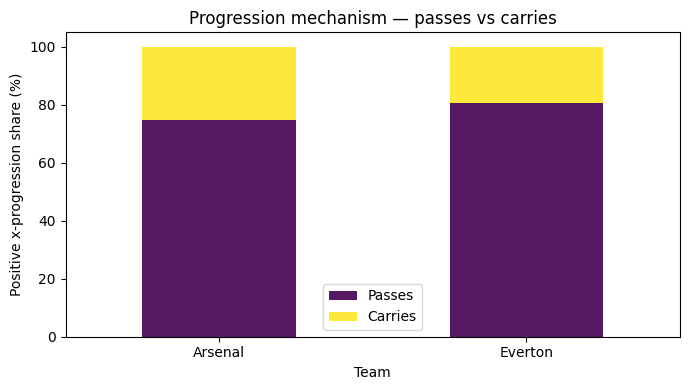

In [22]:
progression_cols = [
    "team",
    "positive_pass_progression",
    "positive_carry_progression",
    "pass_progression_share_pct",
    "carry_progression_share_pct",
    "progression_per_pass",
    "progression_per_carry",
    "progressive_pass_pct",
    "progressive_carry_pct",
]
display(passing_style[progression_cols].round(2))

fig, ax = plt.subplots(figsize=(7, 4))
plot_pass_vs_carry_progression(passing_style, ax=ax)
plt.tight_layout()
plt.show()

### Passing takeaways

The passing metrics sharpen the possession story:

- **Arsenal** use more connected, controlled passing to support buildup from deep. If their `lateral_circulation_pct` and network connectivity are higher, that supports the earlier read that Arsenal recycle and connect through the ball rather than immediately forcing territory.
- **Everton** use more vertical and aerial passing to reach advanced areas faster. Higher forward/long first-pass rates, lower completion, or a more concentrated network would support a direct, channel-oriented structure.
- **Pressure passing** separates composure from risk. A team can face pressure often but remain stable if pressured completion stays close to unpressured completion and the next action avoids turnovers.
- **Progression mechanism** connects passing back to possession. If Arsenal’s carry share is meaningful, their buildup is not only pass circulation; it also relies on players carrying through pressure before the next pass. Everton leaning more heavily on pass progression would fit the longer-ball territorial profile.

### Takeaways

**Arsenal (Wenger)**
- Regular-play chains overwhelmingly start in the **defensive third** — build-from-the-back.
- **Shorter, ground-based passing** (higher completion, fewer long balls and crosses).
- More **carries and dribbles**; slightly longer/faster chains on average.
- On 6+ pass Regular Play chains: **lower directness** — more recycling than vertical play.
- **More pressure faced**, but better completion under pressure; **higher xG** overall.

**Everton (Moyes)**
- More **midfield-started** open play — transitional, less deep buildup.
- **Longer, more aerial** passing; more crosses and final-third passes.
- **Higher territorial rates** (final-third/box entry) but **lower xG efficiency**.
- On 6+ pass chains: longer, more box entries, more shot-ending possessions.
- **Heavier counterpress and duel volume**; turnovers from **incomplete passes**.

**EPL stereotype?** Median open-play chains are ~4 passes / ~11–13 s, but both teams still hit ~10 sustained buildups (6+ passes) and Arsenal peak at **20+ passes** — mixed, not purely direct.


In [25]:
# Notebook state is rebuilt from data and project modules; no dill session needed.
dill.dump_session('../saves/notebook_env.db')